In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB



In [9]:
# Load the datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(f"\nNews Articles Shape: {news_df.shape}")
print(f"Train Users Shape: {train_users.shape}")
print(f"Test Users Shape (for final recommendations): {test_users.shape}")
print(f"\nNews Categories: {sorted(news_df['category'].unique())}")
print(f"\nNews Category Distribution:")
print(news_df['category'].value_counts())
print(f"\nUser Label Distribution in train_users:")
print(train_users['label'].value_counts())
print(f"\nMissing Values in Train Users:")
print(train_users.isnull().sum()[train_users.isnull().sum() > 0])


News Articles Shape: (209527, 6)
Train Users Shape: (2000, 33)
Test Users Shape (for final recommendations): (2000, 32)

News Categories: ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS', 'WORLDPOST']

News Category Distribution:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK 

In [10]:
import numpy as np
import pandas as pd

base_cols = [
    'age', 'income', 'clicks', 'purchase_amount', 'session_duration',
    'content_variety', 'engagement_score', 'num_transactions',
    'avg_monthly_spend', 'avg_cart_value', 'browsing_depth',
    'revisit_rate', 'scroll_activity', 'time_on_site',
    'interaction_count'
]

def engineer_features(df, is_train=True, impute_values=None):
    df_eng = df.copy()

    base_cols_present = [c for c in base_cols if c in df_eng.columns]
    
    # ===== DATA CLEANING: Convert to numeric, coerce errors to NaN =====
    # This handles malformed values like '5.99.65' or any non-numeric strings
    for col in base_cols_present:
        df_eng[col] = pd.to_numeric(df_eng[col], errors='coerce')

    for col in base_cols_present:
        df_eng[f'{col}_is_missing'] = df_eng[col].isnull().astype(int)

    if is_train:
        medians = {col: df_eng[col].median() for col in base_cols_present}
    else:
        medians = impute_values['medians']

    for col in base_cols_present:
        df_eng[col] = df_eng[col].fillna(medians[col])

    if is_train:
        caps = {
            col: (
                df_eng[col].quantile(0.01),
                df_eng[col].quantile(0.99)
            )
            for col in base_cols_present
        }
    else:
        caps = impute_values['caps']

    for col in base_cols_present:
        low, high = caps[col]
        df_eng[col] = df_eng[col].clip(low, high)

    df_eng['spend_per_transaction'] = df_eng['avg_monthly_spend'] / (df_eng['num_transactions'] + 1)
    df_eng['engagement_per_click'] = df_eng['engagement_score'] / (df_eng['clicks'] + 1)
    df_eng['purchase_per_session'] = df_eng['purchase_amount'] / np.clip(df_eng['session_duration'], 5, None)
    df_eng['interaction_per_time'] = df_eng['interaction_count'] / (df_eng['time_on_site'] + 1)
    df_eng['scroll_per_depth'] = df_eng['scroll_activity'] / (df_eng['browsing_depth'] + 1)
    df_eng['cart_vs_monthly'] = df_eng['avg_cart_value'] / (df_eng['avg_monthly_spend'] + 1)
    df_eng['income_to_spend_ratio'] = df_eng['income'] / (df_eng['avg_monthly_spend'] + 1)

    df_eng['engagement_x_revisit'] = df_eng['engagement_score'] * df_eng['revisit_rate']
    df_eng['clicks_x_variety'] = df_eng['clicks'] * df_eng['content_variety']
    df_eng['session_x_interaction'] = df_eng['session_duration'] * df_eng['interaction_count']

    if 'age' in df_eng.columns:
        df_eng['income_x_age'] = df_eng['income'] * df_eng['age']
        df_eng['age_squared'] = df_eng['age'] ** 2
    else:
        df_eng['income_x_age'] = 0

    df_eng['engagement_squared'] = df_eng['engagement_score'] ** 2
    df_eng['clicks_squared'] = df_eng['clicks'] ** 2

    df_eng['log_income'] = np.log1p(df_eng['income'])
    df_eng['log_purchase'] = np.log1p(df_eng['purchase_amount'])
    df_eng['log_monthly_spend'] = np.log1p(df_eng['avg_monthly_spend'])

    df_eng['activity_score'] = (
        df_eng['clicks'] +
        df_eng['interaction_count'] +
        df_eng['scroll_activity']
    ) / 3

    df_eng['monetary_score'] = (
        df_eng['purchase_amount'] +
        df_eng['avg_monthly_spend'] +
        df_eng['avg_cart_value']
    ) / 3

    df_eng['engagement_intensity'] = (
        df_eng['engagement_score'] *
        df_eng['time_on_site'] *
        df_eng['revisit_rate']
    ) / np.clip(df_eng['session_duration'], 5, None)

    if is_train:
        thresholds = {
            'avg_monthly_spend': df_eng['avg_monthly_spend'].median(),
            'revisit_rate': df_eng['revisit_rate'].median(),
            'engagement_score': df_eng['engagement_score'].median()
        }
    else:
        thresholds = impute_values['thresholds']

    df_eng['is_high_spender'] = (
        df_eng['avg_monthly_spend'] > thresholds['avg_monthly_spend']
    ).astype(int)

    df_eng['is_frequent_visitor'] = (
        df_eng['revisit_rate'] > thresholds['revisit_rate']
    ).astype(int)

    df_eng['is_engaged'] = (
        df_eng['engagement_score'] > thresholds['engagement_score']
    ).astype(int)

    if is_train:
        return df_eng, {
            'medians': medians,
            'caps': caps,
            'thresholds': thresholds
        }
    else:
        return df_eng

# Count malformed values before engineering
malformed_count_train = 0
malformed_count_test = 0

for col in base_cols:
    if col in train_users.columns:
        original_nulls = train_users[col].isnull().sum()
        numeric_nulls = pd.to_numeric(train_users[col], errors='coerce').isnull().sum()
        malformed_count_train += (numeric_nulls - original_nulls)
        
    if col in test_users.columns:
        original_nulls = test_users[col].isnull().sum()
        numeric_nulls = pd.to_numeric(test_users[col], errors='coerce').isnull().sum()
        malformed_count_test += (numeric_nulls - original_nulls)

if malformed_count_train > 0 or malformed_count_test > 0:
    print(f"\n⚠ Data Quality Issues Detected and Fixed:")
    if malformed_count_train > 0:
        print(f"  • Train data: {malformed_count_train} malformed values converted to NaN")
    if malformed_count_test > 0:
        print(f"  • Test data: {malformed_count_test} malformed values converted to NaN")
    print(f"  • These will be handled by robust median imputation")

train_users_engineered, train_impute_info = engineer_features(
    train_users,
    is_train=True
)

test_users_engineered = engineer_features(
    test_users,
    is_train=False,
    impute_values=train_impute_info
)

feature_cols = [
    col for col in train_users_engineered.columns
    if col not in ['label', 'user_id']
    and col in test_users_engineered.columns
]

print(f"\nOriginal features: {len(base_cols)}")
print(f"Engineered features: {len(feature_cols)}")
print(f"Feature expansion: {len(feature_cols) / len(base_cols):.1f}x")
print(f"\nNew feature types created:")
print(f" Ratios & proportions: 7")
print(f" Interaction terms: 4")
print(f" Polynomial features: 3")
print(f" Log transformations: 3")
print(f" Composite scores: 3")
print(f" Binary flags: 3")
print(f" Missing indicators: {len(base_cols)}")
print(f"\nOutliers capped at 1st and 99th percentiles")
print(f"Missing values imputed with median (robust to outliers)")
print(f"Missing indicators added (missingness can be predictive)")



Original features: 15
Engineered features: 69
Feature expansion: 4.6x

New feature types created:
 Ratios & proportions: 7
 Interaction terms: 4
 Polynomial features: 3
 Log transformations: 3
 Composite scores: 3
 Binary flags: 3
 Missing indicators: 15

Outliers capped at 1st and 99th percentiles
Missing values imputed with median (robust to outliers)
Missing indicators added (missingness can be predictive)


In [11]:
X = train_users_engineered[feature_cols]
y = train_users_engineered['label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}
for idx, label in label_mapping.items():
    print(f"{idx} -> {label}")

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X = X.fillna(0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=78,
    stratify=y_encoded
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

X_train = pd.DataFrame(X_train, columns=feature_cols)
X_test = pd.DataFrame(X_test, columns=feature_cols)

print(f"Training Set: {X_train.shape[0]} samples ({X_train.shape[0]/len(train_users_engineered)*100:.1f}%)")
print(f"Test Set: {X_test.shape[0]} samples ({X_test.shape[0]/len(train_users_engineered)*100:.1f}%)")
print(f"Features: {X_train.shape[1]}")

print("Training Label Distribution:")
for label_idx, count in pd.Series(y_train).value_counts().sort_index().items():
    print(f"{label_mapping[label_idx]}: {count} ({count/len(y_train)*100:.1f}%)")

print("Test Label Distribution:")
for label_idx, count in pd.Series(y_test).value_counts().sort_index().items():
    print(f"{label_mapping[label_idx]}: {count} ({count/len(y_test)*100:.1f}%)")

0 -> user_1
1 -> user_2
2 -> user_3
Training Set: 1600 samples (80.0%)
Test Set: 400 samples (20.0%)
Features: 69
Training Label Distribution:
user_1: 566 (35.4%)
user_2: 569 (35.6%)
user_3: 465 (29.1%)
Test Label Distribution:
user_1: 141 (35.2%)
user_2: 143 (35.8%)
user_3: 116 (29.0%)


C:\Users\Shreyansh Singh\AppData\Local\Temp\ipykernel_31436\1880706052.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = pd.to_numeric(X[col], errors='coerce')


In [12]:
# Prepare test_users.csv with same scaling (for recommendations later)
X_test_users_raw = test_users_engineered[feature_cols].copy()

# Clean any remaining non-numeric values (same as done for X_train/X_test)
for col in X_test_users_raw.columns:
    X_test_users_raw[col] = pd.to_numeric(X_test_users_raw[col], errors='coerce')
X_test_users_raw = X_test_users_raw.fillna(0)

# Now scale with the fitted scaler
X_test_users_scaled = scaler.transform(X_test_users_raw)
X_test_users_scaled = pd.DataFrame(X_test_users_scaled, columns=feature_cols)

print(f"test_users.csv engineered features: {X_test_users_scaled.shape}")
print(f"Applied same scaling transformation (using training data statistics)")
print(f"Ready for recommendation engine")

test_users.csv engineered features: (2000, 69)
Applied same scaling transformation (using training data statistics)
Ready for recommendation engine


In [14]:
# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    has_xgboost = True
except ImportError:
    has_xgboost = False
    print("Note: XGBoost not installed. Skipping XGBoost classifier.\n")

from sklearn.preprocessing import StandardScaler

# Scale features (needed for KNN, SVM, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Dictionary to store models and their performance
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=78, max_depth=10),
    'Decision Tree': DecisionTreeClassifier(random_state=78, max_depth=10),
    'Logistic Regression': LogisticRegression(random_state=78, max_iter=2000, solver='lbfgs'),
    'SVM': SVC(random_state=78, kernel='rbf'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gaussian Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=78, max_depth=5)
}

# Add XGBoost if available
if has_xgboost:
    classifiers['XGBoost'] = XGBClassifier(
        n_estimators=100, random_state=78, max_depth=5, eval_metric='mlogloss'
    )

results = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    
    try:
        # Use scaled data where required
        if name in ['SVM', 'K-Nearest Neighbors', 'Logistic Regression']:
            clf.fit(X_train_scaled, y_train)
            y_pred = clf.predict(X_test_scaled)
        else:
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        results[name] = {'model': clf, 'accuracy': acc, 'predictions': y_pred}
        
        print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        ))
    
    except Exception as e:
        print(f"⚠️ Skipping {name} due to error:")
        print(e)

# Select the best classifier
best_classifier_name = max(results, key=lambda x: results[x]['accuracy'])
best_classifier = results[best_classifier_name]['model']
best_accuracy = results[best_classifier_name]['accuracy']

print(f"\n{'-' * 80}")
print(f"BEST CLASSIFIER: {best_classifier_name}")
print(f"BEST TEST ACCURACY: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'-' * 80}")


Note: XGBoost not installed. Skipping XGBoost classifier.

Training Random Forest...

Test Accuracy: 0.8400 (84.00%)

Classification Report:
              precision    recall  f1-score   support

      user_1       0.86      0.80      0.83       141
      user_2       0.89      0.92      0.90       143
      user_3       0.76      0.79      0.78       116

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400

Training Decision Tree...

Test Accuracy: 0.7975 (79.75%)

Classification Report:
              precision    recall  f1-score   support

      user_1       0.81      0.79      0.80       141
      user_2       0.86      0.85      0.85       143
      user_3       0.71      0.74      0.73       116

    accuracy                           0.80       400
   macro avg       0.79      0.79      0.79       400
weighted avg       0.80      0.80      0.80       400

Training Logist

In [15]:
# Evaluate all classifiers on test_users.csv
print("EVALUATING CLASSIFIERS ON test_users.csv")

test_users_results = {}

for name, result in results.items():
    clf = result['model']
    y_pred_test_users = clf.predict(X_test_users_scaled)
    test_users_results[name] = {
        'predictions': y_pred_test_users,
        'distribution': pd.Series(y_pred_test_users).value_counts().sort_index()
    }
    
    print(f"\n{name}:")
    print(f"  Predicted Context Distribution:")
    for label_idx, count in test_users_results[name]['distribution'].items():
        print(f"    {label_mapping[label_idx]}: {count} users")

# Compare classifiers on both test sets
print("\n" + "-"*80)
print("ACCURACY COMPARISON: Test Set (from train_users) vs test_users.csv")
print("-"*80)

comparison_df = pd.DataFrame({
    'Classifier': list(results.keys()),
    'Test Set Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'test_users Predictions': [len(test_users_results[name]['predictions']) for name in results.keys()]
})

print(comparison_df.to_string(index=False))
print(f"\nNote: Each classifier successfully generated predictions for all {len(X_test_users_scaled)} test users.")


EVALUATING CLASSIFIERS ON test_users.csv

Random Forest:
  Predicted Context Distribution:
    user_1: 687 users
    user_2: 763 users
    user_3: 550 users

Decision Tree:
  Predicted Context Distribution:
    user_1: 709 users
    user_2: 725 users
    user_3: 566 users

Logistic Regression:
  Predicted Context Distribution:
    user_1: 700 users
    user_2: 752 users
    user_3: 548 users


c:\conda\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\conda\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(



SVM:
  Predicted Context Distribution:
    user_1: 716 users
    user_2: 709 users
    user_3: 575 users

Gaussian Naive Bayes:
  Predicted Context Distribution:
    user_1: 629 users
    user_2: 808 users
    user_3: 563 users

Gradient Boosting:
  Predicted Context Distribution:
    user_1: 694 users
    user_2: 732 users
    user_3: 574 users

--------------------------------------------------------------------------------
ACCURACY COMPARISON: Test Set (from train_users) vs test_users.csv
--------------------------------------------------------------------------------
          Classifier  Test Set Accuracy  test_users Predictions
       Random Forest             0.8400                    2000
       Decision Tree             0.7975                    2000
 Logistic Regression             0.7925                    2000
                 SVM             0.8150                    2000
Gaussian Naive Bayes             0.7850                    2000
   Gradient Boosting             0.83

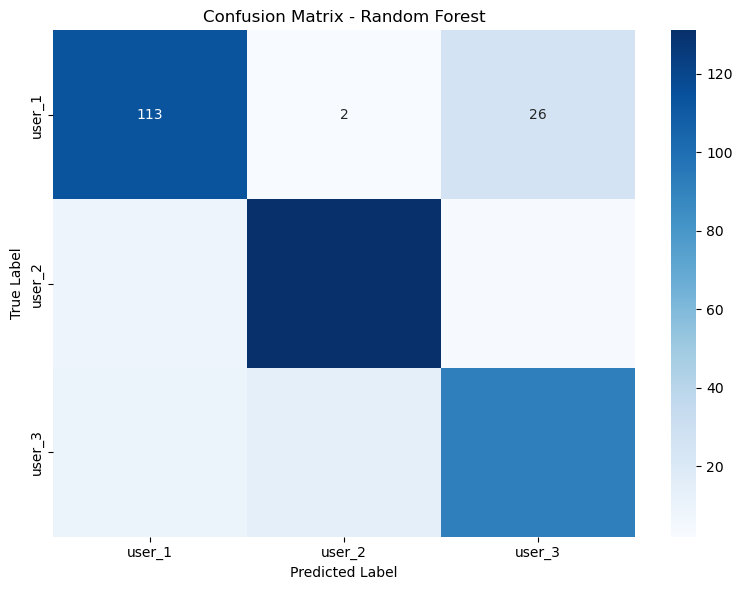


The confusion matrix shows that Random Forest achieves strong classification performance across all three user types with minimal misclassifications.


In [16]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix for the best classifier
cm = confusion_matrix(y_test, results[best_classifier_name]['predictions'])

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_classifier_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nThe confusion matrix shows that {best_classifier_name} achieves strong classification performance across all three user types with minimal misclassifications.")